In [1425]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

## Federal Tax Brackets

In [1426]:
federal_tax_bracket_df = pd.read_csv('data/historical_tax_brackets.csv')
federal_tax_bracket_df.drop(columns=['Unnamed: 2', 'Unnamed: 5', 'Unnamed: 8', 'Unnamed: 11', 'Notes:'], inplace=True)

federal_tax_bracket_df = federal_tax_bracket_df[['Year', 'Single Filer (Rates/Brackets)', 'Unnamed: 9',
                                 'Head of Household (Rates/Brackets)', 'Unnamed: 12',
                                 'Married Filing Jointly (Rates/Brackets)','Unnamed: 3',
                                 'Married Filing Separately (Rates/Brackets)','Unnamed: 6']]
federal_tax_bracket_df.columns = ['year', 'single_r', 'single_bs', 'hoh_r', 'hoh_bs', 'mfj_r', 'mfj_bs', 'mfs_r', 'mfs_bs']

federal_tax_bracket_df['year'] = federal_tax_bracket_df['year'].astype(str).str.extract(r'(\d{4})')

federal_rate_cols = [c for c in federal_tax_bracket_df.columns if c.endswith('_r')]
federal_bracket_start_cols = [c for c in federal_tax_bracket_df.columns if c.endswith('_bs')]

federal_tax_bracket_df[federal_rate_cols] = federal_tax_bracket_df[federal_rate_cols].apply(
  lambda x: pd.to_numeric(x.str.rstrip('%'), errors='coerce') / 100
  )
federal_tax_bracket_df[federal_bracket_start_cols] = federal_tax_bracket_df[federal_bracket_start_cols].apply(
  lambda x: pd.to_numeric(x.replace(r'[$,]', '', regex=True), errors='coerce')
  )

federal_tax_bracket_df.dropna(how='all', inplace=True)
federal_tax_bracket_df.fillna(0, inplace=True)

federal_tax_bracket_df.head()

,year,single_r,single_bs,hoh_r,hoh_bs,mfj_r,mfj_bs,mfs_r,mfs_bs
0,2025,0.10,0.0,0.10,0.0,0.10,0.0,0.10,0.0
1,2025,0.12,11925.0,0.12,17000.0,0.12,23850.0,0.12,11925.0
2,2025,0.22,48475.0,0.22,64850.0,0.22,96950.0,0.22,48475.0
3,2025,0.24,103350.0,0.24,103350.0,0.24,206700.0,0.24,103350.0
4,2025,0.32,197300.0,0.32,197300.0,0.32,394600.0,0.32,197300.0


## FICA

In [1427]:
fica_base_df = pd.read_csv('data/contribution_and_benefit_base.csv')

fica_base_df['year'] = fica_base_df['year'].astype(str)
fica_base_df['base'] = fica_base_df['base'].astype(float)

fica_base_df.head()

,year,base
0,1937,3000.0
1,1938,3000.0
2,1939,3000.0
3,1940,3000.0
4,1941,3000.0


In [1428]:
fica_rates_df = pd.read_csv('data/social_security_and_medicare_tax_rates.csv')
fica_rates_df.drop(columns=['oasdi_employee', 'hi_employee', 'oasdi_self', 'hi_self'], inplace=True)

fica_rates_df['year'] = fica_rates_df['year'].astype(str)
fica_rates_df['total_employee'] = fica_rates_df['total_employee'].astype(float)
fica_rates_df['total_self'] = fica_rates_df['total_self'].astype(float)

fica_rates_df.head()

,year,total_employee,total_self
0,1937,0.01,0.0
1,1938,0.01,0.0
2,1939,0.01,0.0
3,1940,0.01,0.0
4,1941,0.01,0.0


In [1429]:
fica_df = pd.merge(fica_base_df, fica_rates_df, on='year')

fica_df.head()

,year,base,total_employee,total_self
0,1937,3000.0,0.01,0.0
1,1938,3000.0,0.01,0.0
2,1939,3000.0,0.01,0.0
3,1940,3000.0,0.01,0.0
4,1941,3000.0,0.01,0.0


## State

In [1430]:
nj_state_tx_bracket_df = pd.read_csv('data/nj_historical_tax_brackets.csv')

nj_state_tx_bracket_df['year'] = nj_state_tx_bracket_df['year'].astype(str)

nj_state_rate_cols = [c for c in nj_state_tx_bracket_df.columns if c.endswith('_r')]
nj_state_bracket_start_cols = [c for c in nj_state_tx_bracket_df.columns if c.endswith('_bs')]

nj_state_tx_bracket_df[nj_state_rate_cols] = nj_state_tx_bracket_df[nj_state_rate_cols].apply(lambda x: x.astype(float))
nj_state_tx_bracket_df[nj_state_bracket_start_cols] = nj_state_tx_bracket_df[nj_state_bracket_start_cols].apply(lambda x: x.astype(float))

nj_state_tx_bracket_df.head()

,year,single_r,single_bs,hoh_r,hoh_bs,mfj_r,mfj_bs,mfs_r,mfs_bs
0,1976,0.020,0.0,0.020,0.0,0.020,0.0,0.020,0.0
1,1976,0.025,20000.0,0.025,20000.0,0.025,20000.0,0.025,20000.0
2,1977,0.020,0.0,0.020,0.0,0.020,0.0,0.020,0.0
3,1977,0.025,20000.0,0.025,20000.0,0.025,20000.0,0.025,20000.0
4,1978,0.020,0.0,0.020,0.0,0.020,0.0,0.020,0.0


## Inflation Adjustments

In [1431]:
inflation_df = pd.read_csv('data/january_cpi_1913_to_2026.csv')

inflation_df['year'] = inflation_df['year'].astype(str)
inflation_df['cpi'] = inflation_df['cpi'].astype(float)
inflation_df['inflation_adj_ratio'] = inflation_df['cpi'][0] / inflation_df['cpi']

inflation_df.drop(columns=['cpi'], inplace=True)

inflation_df.head()

,year,inflation_adj_ratio
0,2026,1.000000
1,2025,1.023864
2,2024,1.054585
3,2023,1.087181
4,2022,1.156871


In [1432]:
adj_federal_tax_bracket_df = pd.merge(federal_tax_bracket_df, inflation_df, on='year', how='left')
adj_federal_tax_bracket_df.dropna(inplace=True)

adj_federal_tax_bracket_df[federal_bracket_start_cols] = adj_federal_tax_bracket_df[federal_bracket_start_cols].apply(
  lambda bs: (bs * adj_federal_tax_bracket_df['inflation_adj_ratio']).round()
  )
adj_federal_tax_bracket_df.rename(columns={c: f"adj_{c}" for c in federal_bracket_start_cols}, inplace=True)
adj_federal_tax_bracket_df.drop(columns=['inflation_adj_ratio'], inplace=True)

adj_federal_tax_bracket_df.head()

,year,single_r,adj_single_bs,hoh_r,adj_hoh_bs,mfj_r,adj_mfj_bs,mfs_r,adj_mfs_bs
0,2025,0.10,0.0,0.10,0.0,0.10,0.0,0.10,0.0
1,2025,0.12,12210.0,0.12,17406.0,0.12,24419.0,0.12,12210.0
2,2025,0.22,49632.0,0.22,66398.0,0.22,99264.0,0.22,49632.0
3,2025,0.24,105816.0,0.24,105816.0,0.24,211633.0,0.24,105816.0
4,2025,0.32,202008.0,0.32,202008.0,0.32,404017.0,0.32,202008.0


In [1433]:
adj_fica_df = pd.merge(fica_df, inflation_df, on='year', how='left')

adj_fica_df['base'] = (adj_fica_df['base'] * adj_fica_df['inflation_adj_ratio']).round()
adj_fica_df.rename(columns={ 'base': "adj_base" }, inplace=True)
adj_fica_df.drop(columns=['inflation_adj_ratio'], inplace=True)

adj_fica_df.head()

,year,adj_base,total_employee,total_self
0,1937,69203.0,0.01,0.0
1,1938,68715.0,0.01,0.0
2,1939,69697.0,0.01,0.0
3,1940,70198.0,0.01,0.0
4,1941,69203.0,0.01,0.0


In [1434]:
adj_nj_state_tx_bracket_df = pd.merge(nj_state_tx_bracket_df, inflation_df, on='year', how='left')

adj_nj_state_tx_bracket_df[nj_state_bracket_start_cols] = adj_nj_state_tx_bracket_df[nj_state_bracket_start_cols].apply(
  lambda bs: (bs * adj_nj_state_tx_bracket_df['inflation_adj_ratio']).round()
  )
adj_nj_state_tx_bracket_df.rename(columns={c: f"adj_{c}" for c in nj_state_bracket_start_cols}, inplace=True)
adj_nj_state_tx_bracket_df.drop(columns=['inflation_adj_ratio'], inplace=True)

adj_nj_state_tx_bracket_df.head()

,year,single_r,adj_single_bs,hoh_r,adj_hoh_bs,mfj_r,adj_mfj_bs,mfs_r,adj_mfs_bs
0,1976,0.020,0.0,0.020,0.0,0.020,0.0,0.020,0.0
1,1976,0.025,116997.0,0.025,116997.0,0.025,116997.0,0.025,116997.0
2,1977,0.020,0.0,0.020,0.0,0.020,0.0,0.020,0.0
3,1977,0.025,111197.0,0.025,111197.0,0.025,111197.0,0.025,111197.0
4,1978,0.020,0.0,0.020,0.0,0.020,0.0,0.020,0.0


## Functions

In [1435]:
def calculate_progressive_tax(income, brackets_df, rate_col, start_col):
    df = brackets_df.sort_values(start_col)
    
    tax_total = 0
    starts = df[start_col].dropna().values
    rates = df[rate_col].dropna().values
    
    for i in range(len(df)):
        current_start = starts[i]
        current_rate = rates[i]
        next_start = starts[i+1] if i + 1 < len(df) else float('inf')
        
        if income > current_start:
            taxable_in_bracket = min(income, next_start) - current_start
            tax_total += taxable_in_bracket * current_rate
        else:
            break
            
    return tax_total

def get_marginal_rate(total_income, top_x, brackets, r_col, bs_col):
    deducted_income = max(total_income - top_x, 0)

    tax_at_total = calculate_progressive_tax(
        total_income, brackets, r_col, bs_col
    )

    tax_at_deducted = calculate_progressive_tax(
        deducted_income, brackets, r_col, bs_col
    )

    marginal_tax_amount = tax_at_total - tax_at_deducted

    return (marginal_tax_amount / top_x) * 100

def calculate_fica_tax(income, year, is_self_employed=False):
    fica_year_df = adj_fica_df[adj_fica_df['year'] == year]
    assert(len(fica_year_df) <= 1)
    if len(fica_year_df) < 1: return 0
    
    fica_year = fica_year_df.iloc[0]
    rate_col = 'total_self' if is_self_employed else 'total_employee'

    return min(income, fica_year['adj_base']) * fica_year[rate_col]

def calculate_taxable_income(effective_rate, brackets_df, rate_col, start_col):
    df = brackets_df.sort_values(start_col)
    starts = df[start_col].dropna().values
    rates = df[rate_col].dropna().values

    if effective_rate < rates[0] or effective_rate >= rates[-1]:
        return float('inf')
    
    total_income = 0
    total_nominal_tax = 0
    for i in range(len(df)):
        current_rate = rates[i]
        current_start = starts[i]
        next_start = starts[i+1] if i + 1 < len(df) else float('inf')

        if next_start == float('inf'):
            missing_tax = (effective_rate * total_income) - total_nominal_tax
            additional_income = missing_tax / (current_rate - effective_rate)
            total_income += additional_income
            break
  
        bracket_width = next_start - current_start
        max_width = total_income + bracket_width
        max_nominal_tax = total_nominal_tax + bracket_width * current_rate

        if (max_nominal_tax / max_width) > effective_rate:
            missing_tax = (effective_rate * total_income) - total_nominal_tax
            additional_income = missing_tax / (current_rate - effective_rate)
            total_income += additional_income
            break
        else:
            total_income = max_width
            total_nominal_tax = max_nominal_tax
            
    return total_income


In [1436]:
status_map = {
    'Single': ('single_r', 'adj_single_bs'),
    'Head of Household': ('hoh_r', 'adj_hoh_bs'),
    'Married Filing Jointly': ('mfj_r', 'adj_mfj_bs'),
    'Married Filing Separately': ('mfs_r', 'adj_mfs_bs')
}

def plot_effective_rate_by_statuses(taxable_income, is_self_employed=False):
    all_results = []

    # state_brackets = adj_nj_state_tx_bracket_df.groupby('year')
    for year, federal_brackets in adj_federal_tax_bracket_df.groupby('year'):
        year_data = {'year': year}
        fica_tax = calculate_fica_tax(taxable_income, year, is_self_employed)
        for label, (r_col, bs_col) in status_map.items():
            federal_tax = calculate_progressive_tax(taxable_income, federal_brackets, r_col, bs_col)
            # state_tax = calculate_progressive_tax(
            #     taxable_income, state_brackets.get_group(year), r_col, bs_col) if year in state_brackets.groups else 0
            year_data[label] = ((fica_tax + federal_tax
                                #   + state_tax
                                  ) / taxable_income) * 100
        all_results.append(year_data)

    plot_df = pd.DataFrame(all_results).sort_values('year')

    plt.figure(figsize=(12, 6))

    for status in status_map.keys():
        plt.plot(plot_df['year'], plot_df[status], marker='o', label=status)

    plt.title(f'Effective Federal Tax Rate Over Time (${taxable_income:,} Taxable Income)', fontsize=14)
    plt.ylabel('Effective Tax Rate (%)')
    plt.xlabel('Year')
    plt.legend(title="Filing Status")
    plt.grid(True, linestyle='--', alpha=0.7)

    years = plot_df['year'].unique()
    labels_to_show = [y for y in years if int(y) % 5 == 0]
    plt.xticks(labels_to_show, rotation=45)

    plt.tight_layout()
    plt.show()

def plot_effective_rate_by_incomes(status_label, taxable_income_array, is_self_employed=False):
    r_col, bs_col = status_map[status_label]
    
    all_results = []

    # state_brackets = adj_nj_state_tx_bracket_df.groupby('year')
    for year, federal_brackets in adj_federal_tax_bracket_df.groupby('year'):
        year_data = {'year': year}
        for income in taxable_income_array:
            fica_tax = calculate_fica_tax(income, year, is_self_employed)
            federal_tax = calculate_progressive_tax(income, federal_brackets, r_col, bs_col)
            # state_tax = calculate_progressive_tax(
            #     income, state_brackets.get_group(year), r_col, bs_col) if year in state_brackets.groups else 0
            year_data[f"${income:,}"] = ((fica_tax + federal_tax
                                        #    + state_tax
                                           ) / income) * 100
        all_results.append(year_data)

    plot_df = pd.DataFrame(all_results).sort_values('year')

    plt.figure(figsize=(12, 6))
    for income in taxable_income_array:
        column_name = f"${income:,}"
        plt.plot(plot_df['year'], plot_df[column_name], marker='o', label=column_name)

    plt.title(f'Effective Tax Rate Over Time: {status_label}', fontsize=14)
    plt.ylabel('Effective Tax Rate (%)')
    plt.xlabel('Year')
    plt.legend(title="Taxable Income")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    years = plot_df['year'].unique()
    labels_to_show = [y for y in years if int(y) % 5 == 0]
    plt.xticks(labels_to_show, rotation=45)
    
    plt.tight_layout()
    plt.show()

def plot_marginal_rate_by_top_dollars(status_label, income_array, top_x=1000):
    r_col, bs_col = status_map[status_label]
    all_results = []

    for year, federal_brackets in adj_federal_tax_bracket_df.groupby('year'):
        year_data = {'year': year}
        for total_income in income_array:            
            year_data[f"Base ${total_income:,}"] = get_marginal_rate(total_income, top_x, federal_brackets, r_col, bs_col)
            
        all_results.append(year_data)

    plot_df = pd.DataFrame(all_results).sort_values('year')

    plt.figure(figsize=(12, 6))
    for total_income in income_array:
        label = f"Base ${total_income:,}"
        plt.plot(plot_df['year'], plot_df[label], marker='o', label=label)

    plt.title(f'Effective Tax Rate on the TOP ${top_x:,} of Income ({status_label})', fontsize=14)
    plt.ylabel('Marginal Effective Rate (%)')
    plt.xlabel('Year')
    plt.legend(title="Starting Income Level")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    years = plot_df['year'].unique()
    labels_to_show = [y for y in years if int(y) % 5 == 0]
    plt.xticks(labels_to_show, rotation=45)
    
    plt.tight_layout()
    plt.show()

def plot_taxable_income_by_effective_rate(status_label, effective_rate_array, min_year='1950', is_self_employed=False):
    r_col, bs_col = status_map[status_label]
    
    all_results = []

    # state_brackets = adj_nj_state_tx_bracket_df.groupby('year')
    for year, federal_brackets in adj_federal_tax_bracket_df.groupby('year'):
        # TODO: remove range
        if int(year) < int(min_year): continue
        
        year_data = {'year': year}
        for rate in effective_rate_array:
            taxable_income = calculate_taxable_income(rate, federal_brackets, r_col, bs_col)
            # state_tax = calculate_progressive_tax(
            #     income, state_brackets.get_group(year), r_col, bs_col) if year in state_brackets.groups else 0
            year_data[f"{rate:,}"] = taxable_income
        all_results.append(year_data)

    plot_df = pd.DataFrame(all_results).sort_values('year')

    plt.figure(figsize=(12, 6))

    for rate in effective_rate_array:
        column_name = f"{rate:,}"
        plt.plot(plot_df['year'], plot_df[column_name], marker='o', label=column_name)

    plt.title(f'Taxable Income Over Time: {status_label}', fontsize=14)
    plt.ylabel('Taxable Income ($)')
    plt.xlabel('Year')
    plt.legend(title="Effective Rate")
    plt.grid(True, linestyle='--', alpha=0.7)

    years = plot_df['year'].unique()
    labels_to_show = [y for y in years if int(y) % 5 == 0]
    plt.xticks(labels_to_show, rotation=45)

    plt.gca().yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f'${x:,.0f}')
    )

    plt.tight_layout()
    plt.show()

def plot_expected_taxable_income_by_top_dollars(
    status_label,
    income_array,
    top_x=1000,
    min_year='1950'
):
    r_col, bs_col = status_map[status_label]

    all_results = []

    for year, federal_brackets in adj_federal_tax_bracket_df.groupby('year'):
        if int(year) < int(min_year):
            continue

        year_data = {'year': year}

        for total_income in income_array:
            marginal_rate = get_marginal_rate(
                total_income,
                top_x,
                federal_brackets,
                r_col,
                bs_col
            )
            equivalent_income = calculate_taxable_income(
                marginal_rate / 100,
                federal_brackets,
                r_col,
                bs_col
            )
            year_data[f"Base ${total_income:,}"] = equivalent_income

        all_results.append(year_data)

    plot_df = pd.DataFrame(all_results).sort_values('year')

    plt.figure(figsize=(12, 6))

    for total_income in income_array:
        label = f"Base ${total_income:,}"

        plt.plot(
            plot_df['year'],
            plot_df[label],
            marker='o',
            label=label
        )

    plt.title(
        f'Equivalent Taxable Income for Top ${top_x:,} Marginal Rate ({status_label})',
        fontsize=14
    )

    plt.ylabel('Equivalent Taxable Income ($)')
    plt.xlabel('Year')

    plt.legend(title="Original Income Level")

    plt.grid(True, linestyle='--', alpha=0.7)

    years = plot_df['year'].unique()
    labels_to_show = [y for y in years if int(y) % 5 == 0]

    plt.xticks(labels_to_show, rotation=45)

    plt.gca().yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f'${x:,.0f}')
    )

    plt.ylim(0, 1_000_000)

    plt.tight_layout()
    plt.show()

def dollar_formatter(x, pos):
    return f'${x:,.0f}'

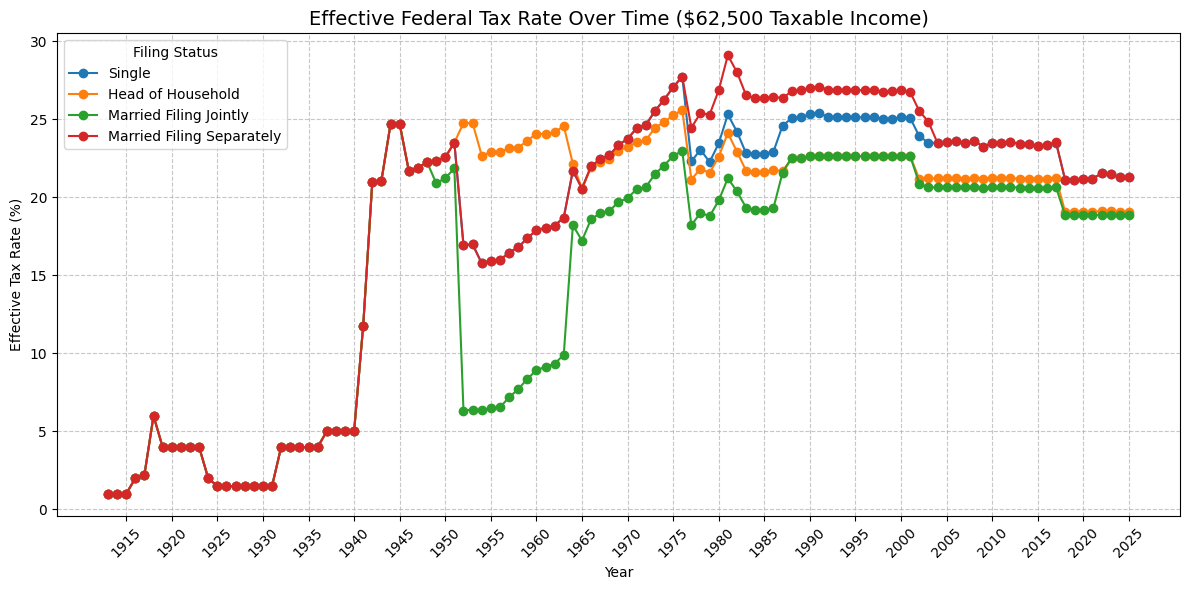

In [1437]:
plot_effective_rate_by_statuses(62_500)

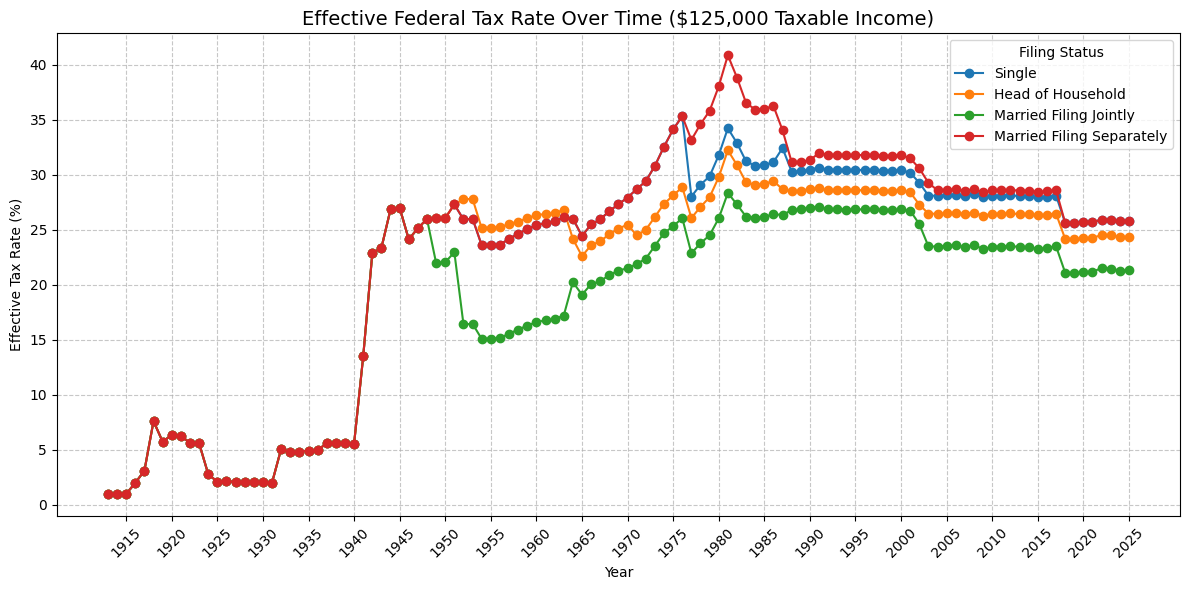

In [1438]:
plot_effective_rate_by_statuses(125_000)

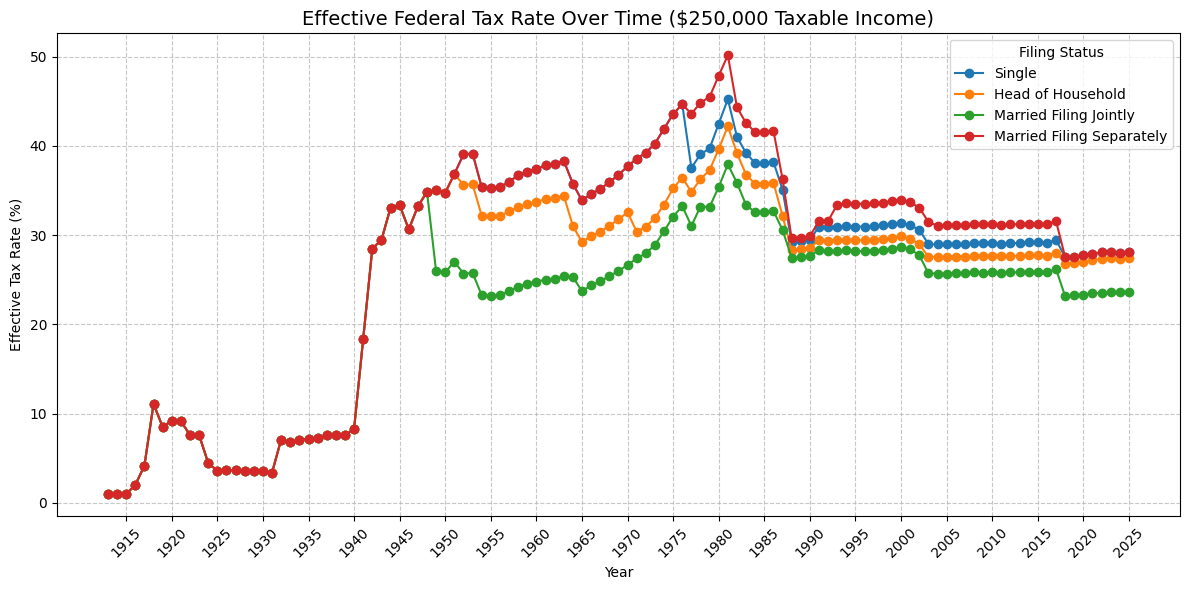

In [1439]:
plot_effective_rate_by_statuses(250_000)

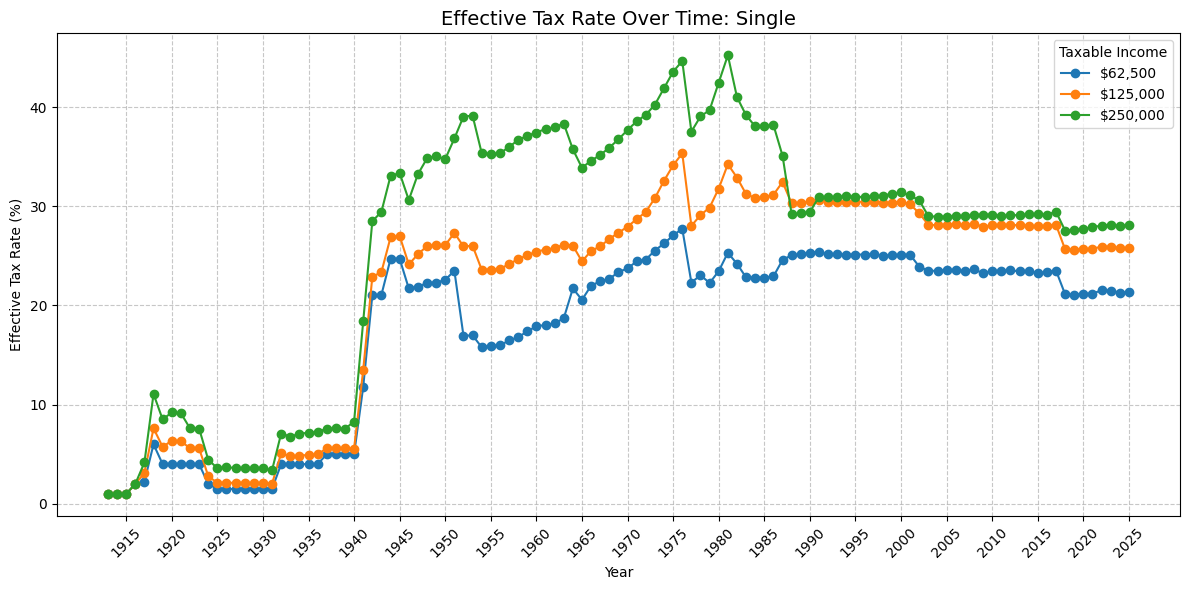

In [1440]:
plot_effective_rate_by_incomes('Single', [62_500, 125_000, 250_000])

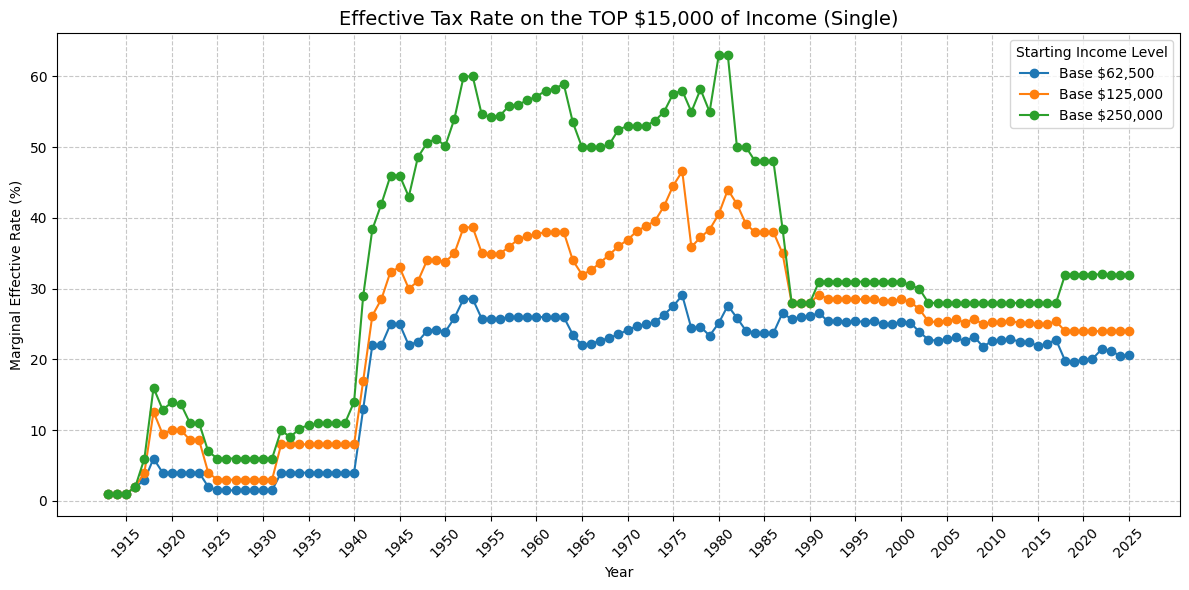

In [1441]:
plot_marginal_rate_by_top_dollars('Single', [62_500, 125_000, 250_000], 15_000)

/var/folders/nf/cp98mn5s3d50sg8yc9jsz1dm0000gn/T/ipykernel_67970/2930749193.py:71: RuntimeWarning: invalid value encountered in scalar divide
  if (max_nominal_tax / max_width) > effective_rate:


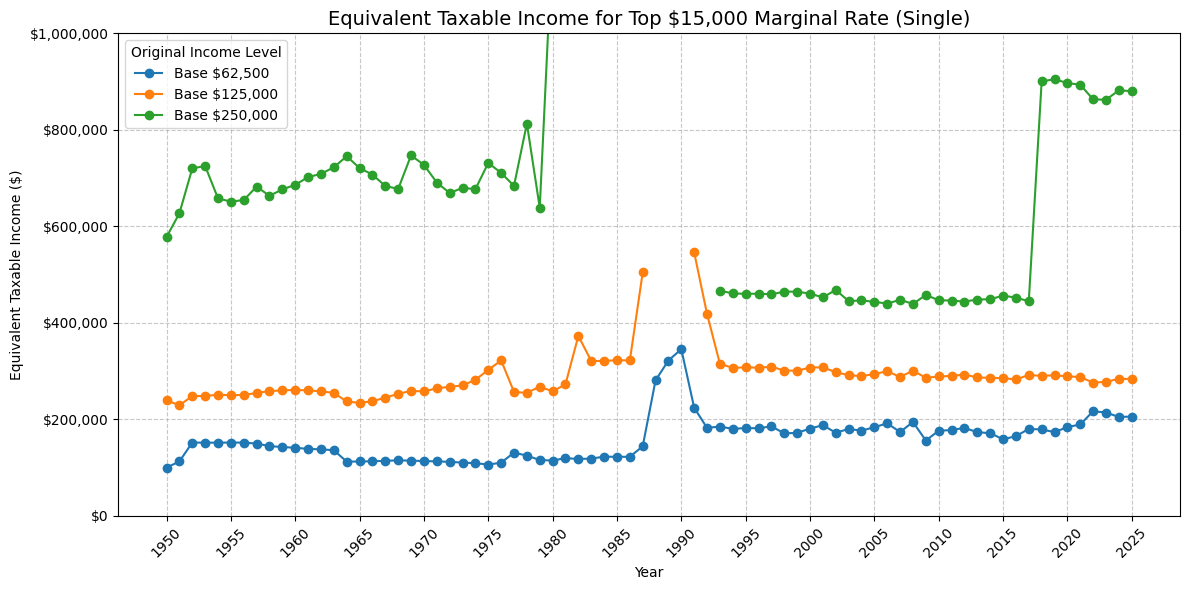

In [1442]:
plot_expected_taxable_income_by_top_dollars('Single', [62_500, 125_000, 250_000], 15_000)